# Loss vs. Dimensions -- development notebook

Interactive counterpart to the standalone scripts in this folder, for iterating on the
loss-vs-dimensions pipeline (fundamental TM00, sidewall scattering + post-processed
non-uniform absorption -- see CLAUDE.md's repo-layout entry for this folder).

**Open item:** `emode_export.build_core_mask_from_geometry`'s trapezoid convention (which edge
`mask` sets, which way `sidewall_angle` tilts) is analytic, not read back from EMode, and is
still unverified. Section 1 below is the geometry sanity check for that.

In [1]:
import sys, os, importlib
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'phase_matching_pipeline'))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import emode_helpers as pmh
import absorption_model as am
import emode_export as ee
import sweep_loss_vs_dimensions as sw
import plot_loss_vs_dimensions as plv

## 1. Verify the core geometry mask convention

Solves one point and plots the shapes/index -- confirm `core` is centered on x=0, `w_core` nm
wide, `h_core` nm tall, narrowing (not widening) toward the top under a positive
`sidewall_angle`. If it looks flipped, fix the sign on the `frac` term in
`emode_export.build_core_mask_from_geometry` to match.

In [2]:
h_check, w_check = 340.0, 400.0

em = pmh.launch_session('geometry_check', clear='all')
try:
    pmh.setup_waveguide(em, sw.ANISOTROPIC_EQUATION, h_check, w_check,
                         sidewall_angle=sw.SIDEWALL_ANGLE)
    em.settings(wavelength=sw.WAVELENGTH_PUMP, num_modes=2,
                x_resolution=sw.X_RESOLUTION, y_resolution=sw.Y_RESOLUTION)
    em.FDM()
    em.plot(component='Shapes')  # opens an interactive window -- close it to continue
    em.plot(component='Index')
finally:
    em.close(save=False)

Headless alternative (saves PNGs instead of opening a window -- useful for sharing/review;
`file_name` must be an absolute path, see CLAUDE.md's known gotchas):

In [ ]:
em = pmh.launch_session('geometry_check', clear='all')
try:
    pmh.setup_waveguide(em, sw.ANISOTROPIC_EQUATION, h_check, w_check,
                         sidewall_angle=sw.SIDEWALL_ANGLE)
    em.settings(wavelength=sw.WAVELENGTH_PUMP, num_modes=2,
                x_resolution=sw.X_RESOLUTION, y_resolution=sw.Y_RESOLUTION)
    em.FDM()
    em.plot(component='Shapes', file_name=os.path.abspath('geometry_check_shapes.png'))
    em.plot(component='Index', file_name=os.path.abspath('geometry_check_index.png'))
finally:
    em.close(save=False)

Cross-check `build_core_mask_from_geometry` against the same point -- overlay the analytic
mask's outline and compare it by eye to the plots above.

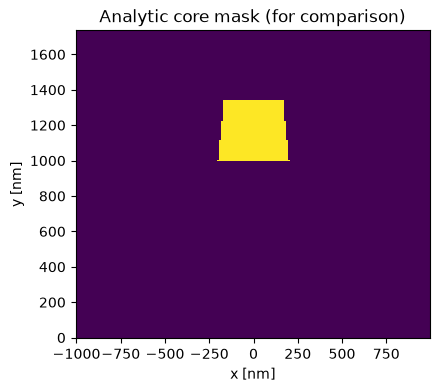

In [3]:
x_dummy = np.arange(-1000.0, 1000.0, sw.X_RESOLUTION)
y_dummy = np.arange(0.0, sw.SUBSTRATE_HEIGHT + h_check + 400.0, sw.Y_RESOLUTION)
# confirmed via em.plot() above: the core sits directly on top of the substrate, at
# y=SUBSTRATE_HEIGHT -- not centered in the window
mask = ee.build_core_mask_from_geometry(x_dummy, y_dummy, h_check, w_check, sw.SIDEWALL_ANGLE,
                                         sw.SUBSTRATE_HEIGHT)

plt.figure(figsize=(5, 4))
plt.pcolormesh(x_dummy, y_dummy, mask, shading='auto')
plt.xlabel('x [nm]'); plt.ylabel('y [nm]'); plt.title('Analytic core mask (for comparison)')
plt.gca().set_aspect('equal')

## 2. Re-run the EMode-output diagnostic (optional)

Only needed again if you change solver settings enough to worry the return shapes/units
might differ (e.g. switching to EME, or a very different geometry) -- otherwise skip to 3.

In [ ]:
import inspect_emode_outputs
importlib.reload(inspect_emode_outputs)
inspect_emode_outputs.main()

## 3. Run the loss-vs-dimensions sweep

Edit the constants at the top of `sweep_loss_vs_dimensions.py` (geometry sweep grid,
roughness assumptions, solver settings) then re-run this cell -- `importlib.reload` picks up
the edit without restarting the kernel. Checkpointed: re-running skips points already done in
`loss_vs_dimensions_results.csv`, so an interrupted run or one transient EMode.exe failure
(see CLAUDE.md's known gotchas) only costs the points not yet solved.

In [4]:
importlib.reload(ee)
importlib.reload(sw)
sw.main()

0 point(s) already done, 15 remaining.

=== h=340.0, w=300.0 ===
  n_eff=2.01691, scattering_loss=1.8e+03 dB/m

=== h=340.0, w=350.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=400.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=450.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=500.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=550.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=600.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=650.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=700.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=750.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=800.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=850.0 ===
  FAILED: EModeError('EMode failed to launch.')

=== h=340.0, w=900.0 ===
  FAILED: EModeError('EMode failed to launch.')



## 4. Plot results

Uses `plot_loss_vs_dimensions.py`'s `MECHANISMS` list -- produces the totals figure
(`loss_vs_dimensions.png`) plus a per-physical-mechanism breakdown figure
(`loss_by_mechanism.png`, one subplot per height).

Saved loss_vs_dimensions.png


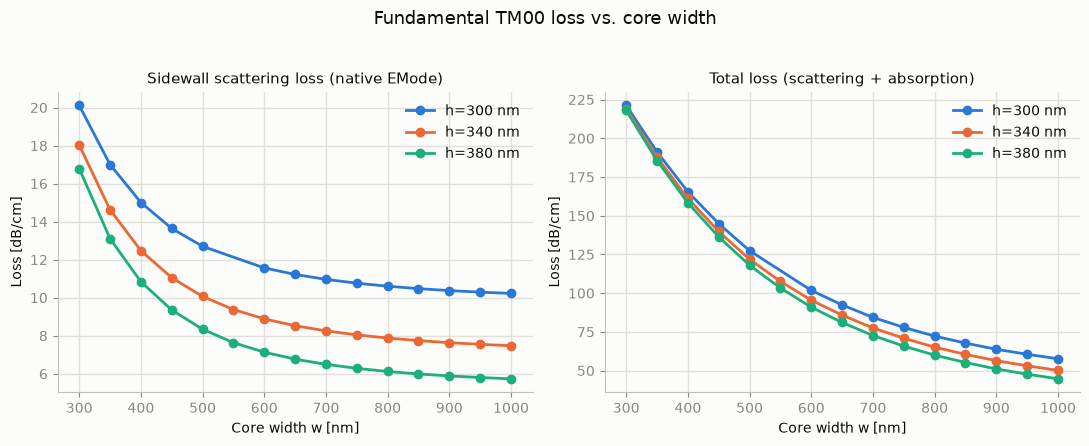

In [5]:
importlib.reload(plv)
plv.main()

## 5. Explore absorption assumptions interactively (no EMode calls)

Loads the sweep's exported fields directly and lets you sweep alpha0/L by hand -- faster
than editing `plot_loss_vs_dimensions.py` and re-running for quick exploration.

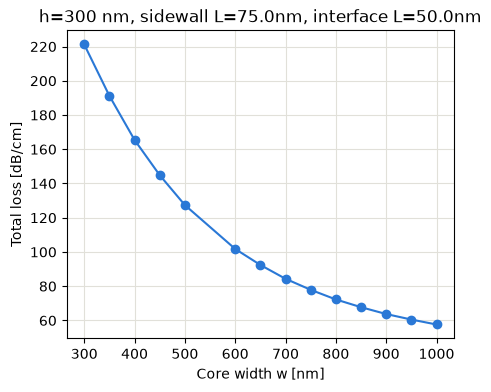

In [6]:
import copy

# Start from plot_loss_vs_dimensions.py's MECHANISMS list (single source of truth) and tweak
# whichever one(s) you're investigating -- deepcopy so this doesn't mutate the shared list.
mechanisms = copy.deepcopy(plv.MECHANISMS)
for m in mechanisms:
    if m['name'] == 'Sidewall damage':
        m['alpha0'] = 3.0e4
        m['L'] = 60.0

rows = plv.load_results(sw.RESULTS_CSV)
h_pick = sorted(set(r['h_core'] for r in rows))[0]
h_rows = sorted((r for r in rows if r['h_core'] == h_pick), key=lambda r: r['w_core'])

widths, totals = [], []
per_mechanism = {m['name']: [] for m in mechanisms}
for r in h_rows:
    data = np.load(r['export_path'])
    losses = am.compute_mechanism_losses(
        data['core_mask'], dx=float(data['x'][1] - data['x'][0]), y=data['y'], Sz=data['Sz'],
        mechanisms=mechanisms)
    widths.append(r['w_core'])
    totals.append((r['scattering_loss_dB_per_m'] + sum(losses.values())) / 100)  # dB/cm
    for name, val in losses.items():
        per_mechanism[name].append(val / 100)

plt.figure(figsize=(6.5, 4.5))
for i, (name, vals) in enumerate(per_mechanism.items()):
    plt.plot(widths, vals, '-o', color=plv.MECHANISM_COLORS[i % len(plv.MECHANISM_COLORS)],
             markersize=4, label=name)
plt.plot(widths, totals, '-o', color='black', linewidth=2.5, label='Total (scattering + all)')
plt.xlabel('Core width w [nm]'); plt.ylabel('Loss [dB/cm]')
plt.title(f'h={h_pick:.0f} nm')
plt.legend(fontsize=8, frameon=False)
plt.grid(True, color='#e1e0d9'); plt.gca().set_axisbelow(True)